In [1]:
!pip install datasets pycddlib umap-learn dask dask-expr cvxopt seaborn plotly --break-system-packages

  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached pycddlib-3.0.2.tar.gz (31 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached dask-2026.3.0-py3-none-any.whl.metadata (3.9 kB)
  Using cached dask_expr-2.0.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached cvxopt-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (43 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached plotly-6.6.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pyarrow-23.0.1-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (3.1 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using c

In [11]:
import os
from datasets import load_dataset
from datasets import Dataset
from collections import defaultdict
from collections import Counter

import pandas as pd
pd.set_option("display.max_rows", None)

import random
import numpy as np

from numba import jit

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report

from scipy.spatial import ConvexHull

import polytope as pc

import cdd

from umap import UMAP

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

Dataset hat 473800776 Zeilen und die Spalten: 'vertices', 'vertex_count', 'facet_count', 'point_count', 'dual_point_count', 'h11', 'h12', 'euler_characteristic'.

In [5]:
# Do this only once!
dataset = load_dataset(
    "calabi-yau-data/polytopes-4d",
    split="full",
    cache_dir="/home/jovyan/.cache/huggingface"
)
print(dataset)

Generating full split: 100%|██████████| 473800776/473800776 [04:08<00:00, 1906080.08 examples/s]


Dataset({
    features: ['vertices', 'vertex_count', 'facet_count', 'point_count', 'dual_point_count', 'h11', 'h12', 'euler_characteristic'],
    num_rows: 473800776
})


In [9]:
# After downloading data work in offline mode!
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

vertex_count_data = load_dataset(
    "calabi-yau-data/polytopes-4d",
    split="full",
    cache_dir="/home/jovyan/.cache/huggingface"
).select_columns(["vertex_count"])

print(vertex_count_data)


Dataset({
    features: ['vertex_count'],
    num_rows: 473800776
})


In [10]:
batch_size = 100_000
vertex_counts = pd.Series(dtype="int64")

rows = len(vertex_count_data)
print(f"Total rows: {rows:,}")

for start in range(0, rows, batch_size):
    end = min(start + batch_size, rows)
    batch = vertex_count_data.select(
        range(start, end)
    ).to_pandas()

    vertex_counts = vertex_counts.add(
        batch["vertex_count"].value_counts(),
        fill_value=0
    )

vertex_counts = vertex_counts.astype("int64").sort_index()

Total rows: 473,800,776


In [13]:
vertex_counts_4d_df = (vertex_counts.rename_axis("vertex_count").reset_index(name="count"))
print(vertex_counts_4d_df)

    vertex_count     count
0              5      1561
1              6     24189
2              7    177446
3              8    834638
4              9   2867955
5             10   7725801
6             11  16608387
7             12  29270253
8             13  43458000
9             14  56060584
10            15  64085869
11            16  65615931
12            17  59972682
13            18  48703033
14            19  34847821
15            20  21913680
16            21  12070919
17            22   5826221
18            23   2450720
19            24    898929
20            25    284696
21            26     78468
22            27     18417
23            28      3781
24            29       647
25            30       114
26            31        23
27            32         8
28            33         2
29            36         1


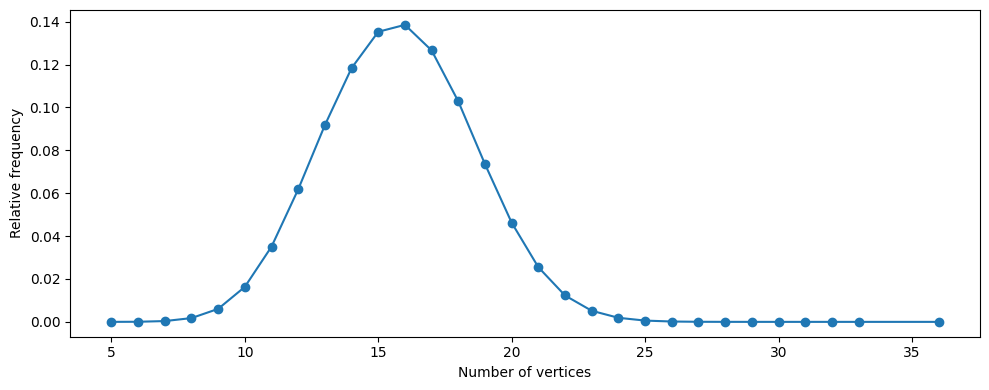

In [23]:
vertex_counts_4d_df["relative_frequency"] = (
    vertex_counts_4d_df["count"] /
    vertex_counts_4d_df["count"].sum()
)

plt.figure(figsize=(10, 4))

plt.plot(
    vertex_counts_4d_df["vertex_count"],
    vertex_counts_4d_df["relative_frequency"],
    marker="o",
    linestyle="-"
)

plt.xlabel("Number of vertices")
plt.ylabel("Relative frequency")


plt.tight_layout()
plt.savefig("poly4d-normalized-vertex-dist.png", dpi=300, bbox_inches="tight")
plt.show()

# Analyze simple symmetries

In [16]:
symmetry_data = load_dataset(
    "calabi-yau-data/polytopes-4d",
    split="full",
    cache_dir="/home/jovyan/.cache/huggingface"
).select_columns([
    "vertex_count",
    "point_count",
    "dual_point_count"
])
symmetry_data

Dataset({
    features: ['vertex_count', 'point_count', 'dual_point_count'],
    num_rows: 473800776
})

In [17]:
BATCH_SIZE = 100_000
MAX_PER_VERTEX = 3_000
rng = 42

samples = defaultdict(list)
rows = len(symmetry_data)

for start in range(0, rows, BATCH_SIZE):
    end = min(start + BATCH_SIZE, rows)
    batch = symmetry_data.select(range(start, end)).to_pandas()

    for vc, sub in batch.groupby("vertex_count"):
        remaining = MAX_PER_VERTEX - len(samples[vc])
        if remaining <= 0:
            continue

        take = sub.sample(
            n=min(len(sub), remaining),
            random_state=rng
        )

        samples[vc].append(take)

# Zusammenbauen
sampled_data = pd.concat(
    [pd.concat(v, ignore_index=True) for v in samples.values()],
    ignore_index=True
)

sampled_data.head(), len(sampled_data)

(   vertex_count  point_count  dual_point_count
 0             5           45                97
 1             5          281                31
 2             5           17                65
 3             5           37                25
 4             5           17                27,
 13152929)

## Vertex to point ratio distribution

In [18]:
sampled_data["vertex_to_point_ratio"] = (
    sampled_data["vertex_count"] / sampled_data["point_count"]
)

sampled_data["vertex_to_dual_point_ratio"] = (
    sampled_data["vertex_count"] / sampled_data["dual_point_count"]
)

sampled_data["vertex_count"].value_counts().sort_index()

vertex_count
5        1561
6        3000
7        8997
8       26964
9       89565
10     230997
11     487139
12     838929
13    1210605
14    1528359
15    1720239
16    1755504
17    1622700
18    1345172
19     986274
20     635910
21     358619
22     175289
23      77675
24      29955
25       8997
26       3684
27       3000
28       3000
29        647
30        114
31         23
32          8
33          2
36          1
Name: count, dtype: int64

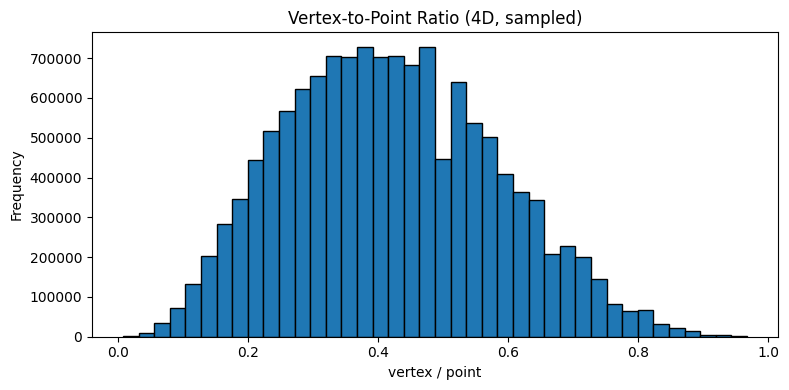

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(
    sampled_data["vertex_to_point_ratio"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("vertex / point")
plt.ylabel("Frequency")
plt.title("Vertex-to-Point Ratio (4D, sampled)")
plt.tight_layout()
plt.show()

<module 'matplotlib.pyplot' from '/opt/conda/lib/python3.11/site-packages/matplotlib/pyplot.py'>

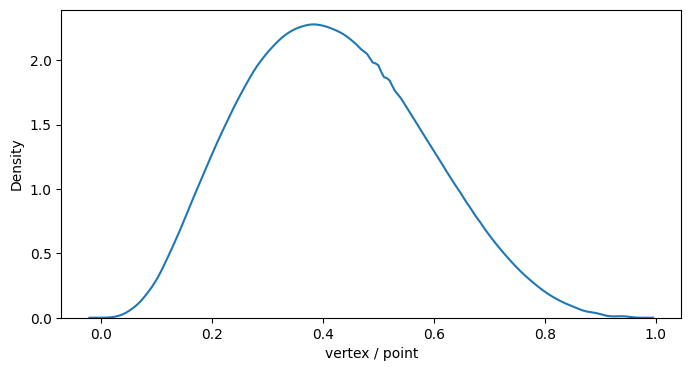

In [20]:
plt.figure(figsize=(8, 4))

sns.kdeplot(
    sampled_data["vertex_to_point_ratio"],
    bw_adjust=1.5,
    fill=False
)

plt.xlabel("vertex / point")
plt

## Plot vertex to point ratio distributions by vertex count

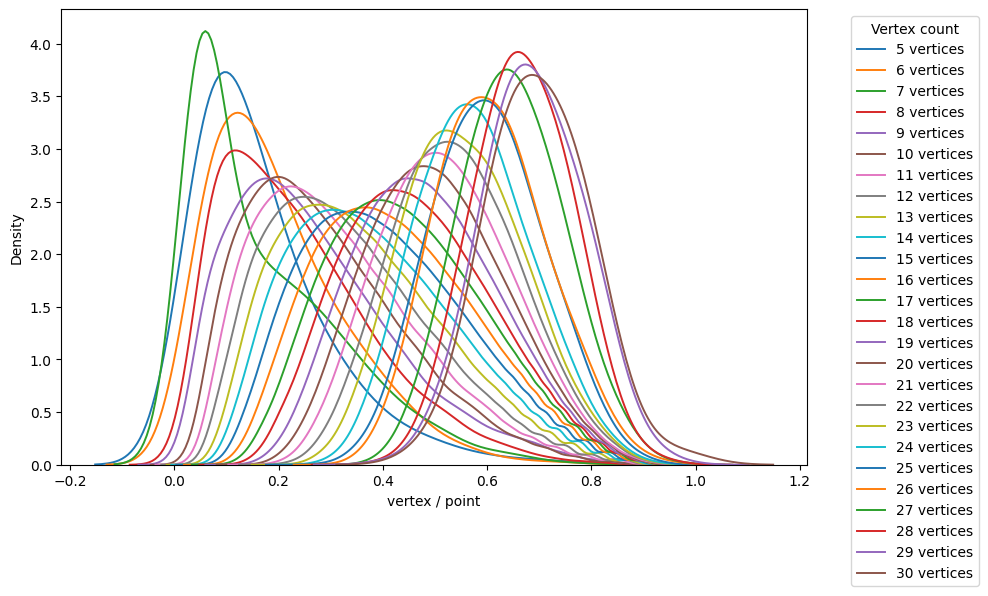

In [26]:
plt.figure(figsize=(10, 6))

for vc in sorted(sampled_data["vertex_count"].unique()):
    subset = sampled_data[sampled_data["vertex_count"] == vc]
    if len(subset) < 100:
        continue

    sns.kdeplot(
        subset["vertex_to_point_ratio"],
        label=f"{vc} vertices",
        bw_adjust=1.8,
        linewidth=1.4
    )

plt.xlabel("vertex / point")
plt.ylabel("Density")
plt.legend(
    title="Vertex count",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.savefig("poly4d-vertex-point-ratio-by-vertexcount.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot vertex to dual point ratio distributions by vertex count

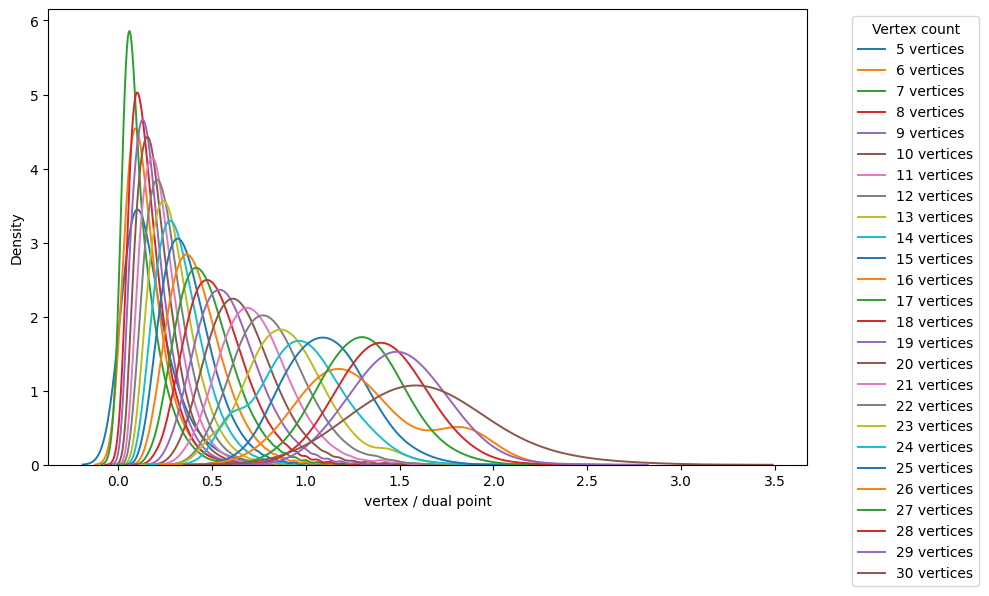

In [27]:
plt.figure(figsize=(10, 6))

for vc in sorted(sampled_data["vertex_count"].unique()):
    subset = sampled_data[sampled_data["vertex_count"] == vc]
    if len(subset) < 100:
        continue

    sns.kdeplot(
        subset["vertex_to_dual_point_ratio"],
        label=f"{vc} vertices",
        bw_adjust=2.2,
        linewidth=1.4
    )

plt.xlabel("vertex / dual point")
plt.ylabel("Density")
plt.legend(
    title="Vertex count",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.savefig("poly4d-vertex-dualpoint-ratio-by-vertexcount.png", dpi=300, bbox_inches="tight")
plt.show()